# CLIP + SAM

In [5]:
# download model checkpoint from google drive drive and move it to checkpoints folder

#!gdown 'https://drive.google.com/uc?id=10QQT131P5jJ6s0PQ7o-xZM3MYAzc6FDR' -O sam_vit_l_0b3195.pth

# install necessary modules
import sys

!{sys.executable} -m pip install torch opencv-python Pillow
!{sys.executable} -m pip install git+https://github.com/openai/CLIP.git
!{sys.executable} -m pip install git+https://github.com/facebookresearch/segment-anything.git


[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip
  Cloning https://github.com/openai/CLIP.git to /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-7pug6pea
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-7pug6pea
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip
  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-p7sgfauj
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-p7sgfauj


In [6]:
import cv2
from segment_anything import build_sam, SamAutomaticMaskGenerator
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import clip
import torch
import numpy as np

In [20]:
# load SAM

sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

#sam_checkpoint = "../checkpoints/sam_vit_b_01ec64.pth"
sam_checkpoint = "../checkpoints/sam_vit_l_0b3195.pth"
model_type = "vit_l"

#default
device = "cpu"

#NVIDIA
#device = "cuda"

#M1 chips
#device = "mps"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)

In [16]:
#image_path = "../images/190605168479_01.png"
#image_path = "../images/190605154458_01.png"
image_path = "../images/190605154458_01.png"

In [21]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
masks = mask_generator.generate(image)

In [9]:
def convert_box_xywh_to_xyxy(box):
    x1 = box[0]
    y1 = box[1]
    x2 = box[0] + box[2]
    y2 = box[1] + box[3]
    return [x1, y1, x2, y2]

In [10]:
def segment_image(image, segmentation_mask):
    image_array = np.array(image)
    
    segmented_image_array = np.zeros_like(image_array)
    segmented_image_array[segmentation_mask] = image_array[segmentation_mask]
    segmented_image = Image.fromarray(segmented_image_array)
    
    black_image = Image.new("RGB", image.size, (0, 0, 0))
    
    transparency_mask = np.zeros_like(segmentation_mask, dtype=np.uint8)
    transparency_mask[segmentation_mask] = 255
    transparency_mask_image = Image.fromarray(transparency_mask, mode='L')
    
    black_image.paste(segmented_image, mask=transparency_mask_image)
    return black_image

In [22]:
# Cut out all masks

import matplotlib.pyplot as plt

image = Image.open(image_path)
cropped_boxes = []

for mask in masks:
    
    # Access the 'segmentation' key to get the mask
    segmentation_mask = mask['segmentation']
    
    # Display the segmentation mask
    #plt.figure(figsize=(20, 20))
    #plt.imshow(segmentation_mask, cmap='gray')
    #plt.axis('off')
    #plt.show()
    cropped_boxes.append(segment_image(image, mask["segmentation"]).crop(convert_box_xywh_to_xyxy(mask["bbox"])))

In [28]:
# Load CLIP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)

In [13]:
@torch.no_grad()
def retriev(elements: list[Image.Image], positive_texts: list[str], negative_texts: list[str]) -> torch.Tensor:
    preprocessed_images = [preprocess(image).to(device) for image in elements]
    tokenized_positive_texts = clip.tokenize(positive_texts).to(device)
    tokenized_negative_texts = clip.tokenize(negative_texts).to(device)
    
    stacked_images = torch.stack(preprocessed_images)
    image_features = model.encode_image(stacked_images)
    positive_text_features = model.encode_text(tokenized_positive_texts)
    negative_text_features = model.encode_text(tokenized_negative_texts)
    
    image_features /= image_features.norm(dim=-1, keepdim=True)
    positive_text_features /= positive_text_features.norm(dim=-1, keepdim=True)
    negative_text_features /= negative_text_features.norm(dim=-1, keepdim=True)
    
    positive_probs = 100. * image_features @ positive_text_features.T
    negative_probs = 100. * image_features @ negative_text_features.T
    
    avg_positive_probs = positive_probs.mean(dim=1)
    avg_negative_probs = negative_probs.mean(dim=1)
    
    final_probs = avg_positive_probs - avg_negative_probs
    
    return final_probs.softmax(dim=0)

In [14]:
def get_indices_of_values_above_threshold(scores, threshold):
    return torch.nonzero(scores > threshold).squeeze().tolist()

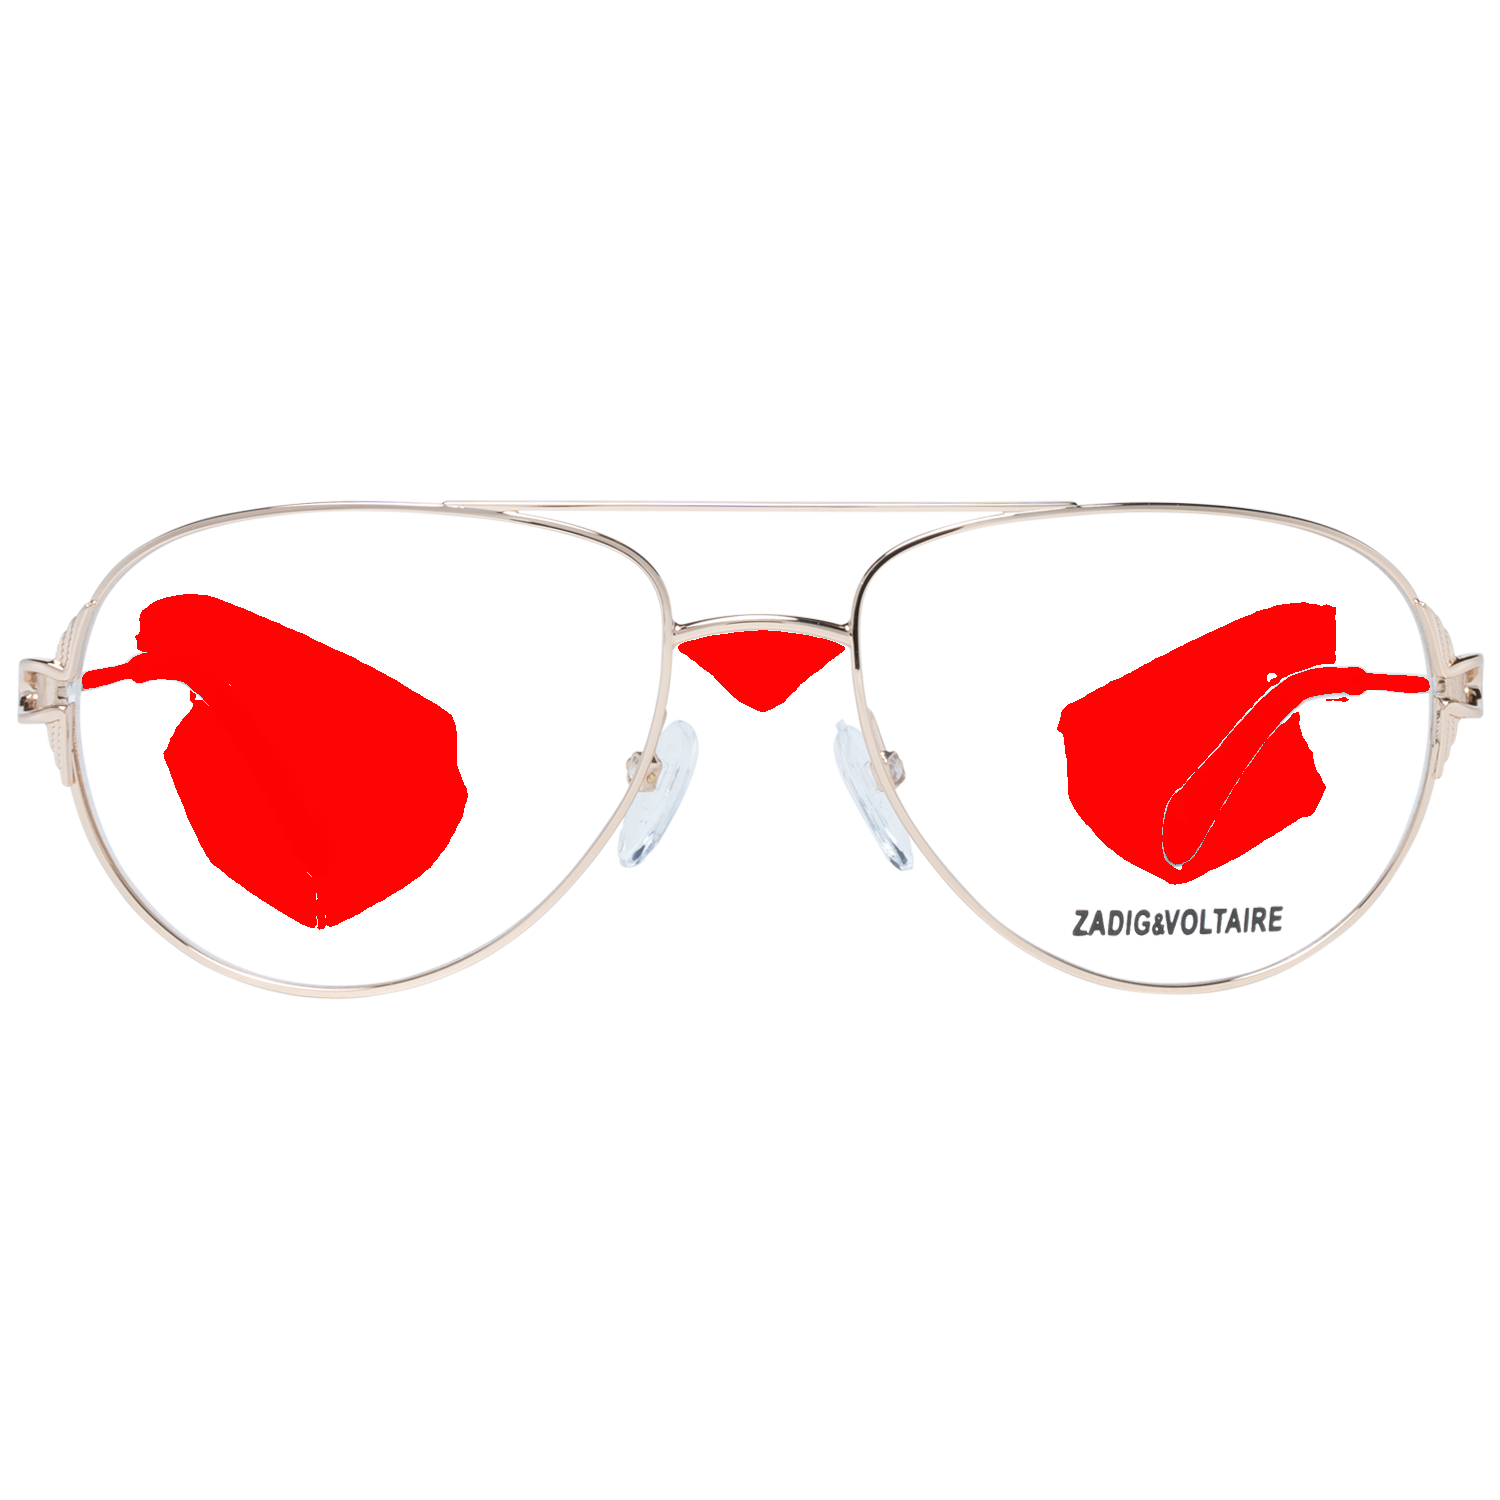

In [29]:
#scores = retriev(cropped_boxes, "temple arms")
positive_texts = ["side arms", "temple arms"]
negative_texts = ["top bar"]
scores = retriev(cropped_boxes, positive_texts, negative_texts)
indices = get_indices_of_values_above_threshold(scores, 0.05)

segmentation_masks = []

for seg_idx in indices:
    segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
    segmentation_masks.append(segmentation_mask_image)
    

original_image = Image.open(image_path)
overlay_image = Image.new('RGBA', image.size, (0, 0, 0, 0))
overlay_color = (255, 0, 0, 250)

draw = ImageDraw.Draw(overlay_image)
for segmentation_mask_image in segmentation_masks:
    draw.bitmap((0, 0), segmentation_mask_image, fill=overlay_color)

result_image = Image.alpha_composite(original_image.convert('RGBA'), overlay_image)
result_image

In [30]:
@torch.no_grad()
def retriev_back(elements: list[Image.Image], search_text: str) -> int:
    preprocessed_images = [preprocess(image).to(device) for image in elements]
    tokenized_text = clip.tokenize([search_text]).to(device)
    stacked_images = torch.stack(preprocessed_images)
    image_features = model.encode_image(stacked_images)
    text_features = model.encode_text(tokenized_text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    probs = 100. * image_features @ text_features.T
    return probs[:, 0].softmax(dim=0)

1500
(760, 630)
(760, 612)


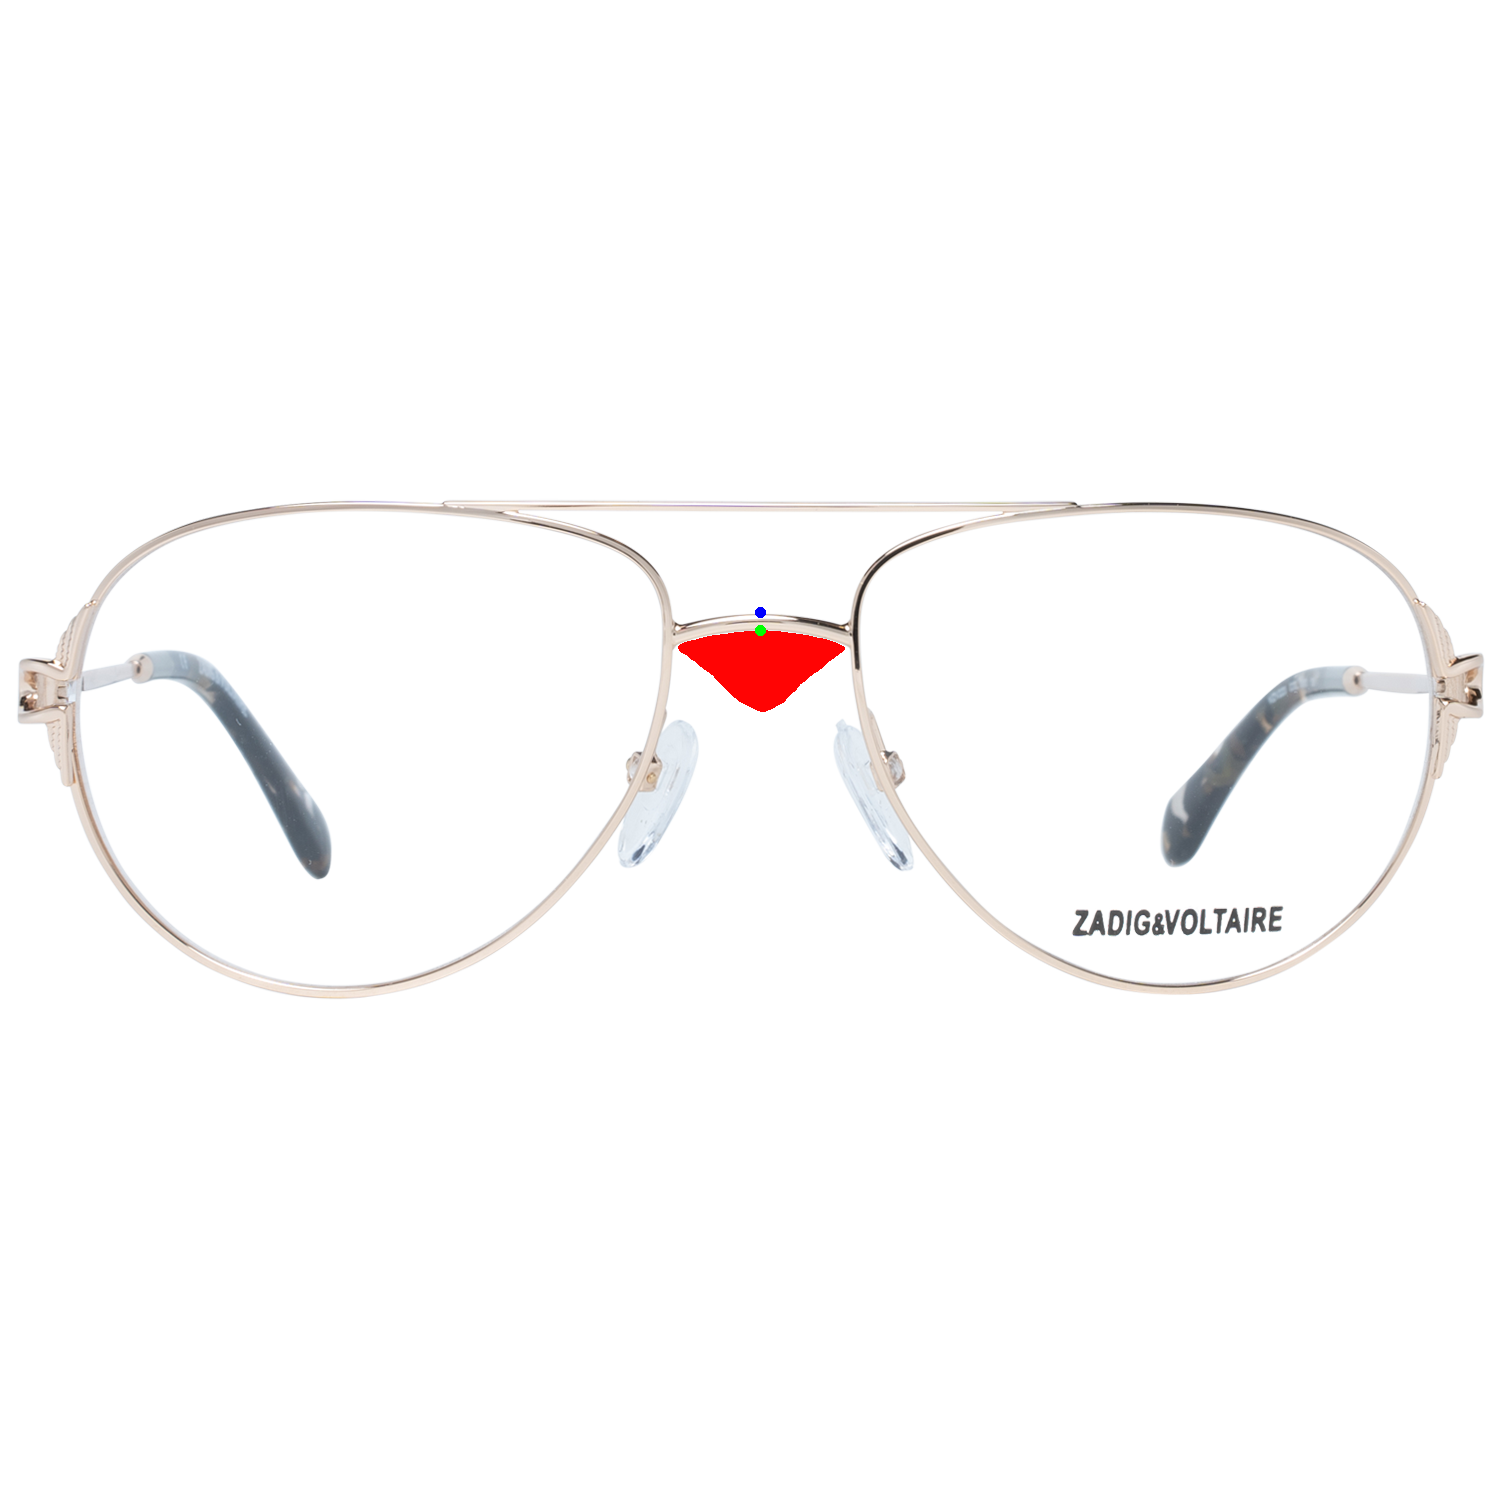

In [56]:
# obtain mask that represents the nose part

# Function to calculate the centroid of a mask
def calculate_centroid(mask):
    # Get the coordinates of all the pixels in the mask
    y_indices, x_indices = np.nonzero(mask)
    centroid_x = np.mean(x_indices)
    centroid_y = np.mean(y_indices)
    return (centroid_x, centroid_y)

# Function to calculate the Euclidean distance between two points
def calculate_distance(point1, point2):
    return np.sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2)


scores = retriev_back(cropped_boxes, "top bridge") #top bar for the bridge itself
indices = get_indices_of_values_above_threshold(scores, 0.05)

segmentation_masks = []

for seg_idx in indices:
    segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
    segmentation_masks.append(segmentation_mask_image)
    

original_image = Image.open(image_path)
overlay_image = Image.new('RGBA', image.size, (0, 0, 0, 0))
overlay_color = (255, 0, 0, 250)

image_width, image_height = original_image.size
image_center = (image_width / 2, image_height / 2)

# finding central mask
min_distance = float('inf')
most_central_mask = None

for mask in segmentation_masks:
    centroid = calculate_centroid(mask)
    distance_to_center = calculate_distance(centroid, image_center)
    if distance_to_center < min_distance:
        min_distance = distance_to_center
        most_central_mask = mask
        
img = np.array(original_image)

# pick center of the glasses
mask_center = int(calculate_centroid(most_central_mask)[0])
        
# pick top of the mask
lower_point = (mask_center, np.min(np.argwhere(np.array(most_central_mask) > 0)[:, 0]))
higher_point = (mask_center, np.max(np.argwhere(img[:lower_point[1], original_image.width // 2] == 0)))

print(original_image.width)

# check
print(lower_point)
print(higher_point)

# Create an overlay image
overlay_image = Image.new('RGBA', original_image.size, (0, 0, 0, 0))
overlay_color = (255, 0, 0, 250)
draw = ImageDraw.Draw(overlay_image) 

# Convert the most central mask to a PIL image
draw.bitmap((0, 0), most_central_mask, fill=overlay_color)
draw.bitmap((0, 0), most_central_mask, fill=overlay_color)

circle_radius = 5  # Set the radius of the circles

# Draw lower_point circle
if lower_point:
    draw.ellipse((lower_point[0] - circle_radius, lower_point[1] - circle_radius,
                  lower_point[0] + circle_radius, lower_point[1] + circle_radius),
                 fill=(0, 255, 0, 255))  # Green color with full opacity

# Draw higher_point circle
if higher_point:
    draw.ellipse((higher_point[0] - circle_radius, higher_point[1] - circle_radius,
                  higher_point[0] + circle_radius, higher_point[1] + circle_radius),
                 fill=(0, 0, 255, 255))  # Blue color with full opacity


# Composite the original image with the overlay
result_image = Image.alpha_composite(original_image.convert('RGBA'), overlay_image)
result_image

In [19]:
# wrapping into he function
def process_with_NLP(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    masks = mask_generator.generate(image)
    
    image = Image.open(image_path)
    cropped_boxes = []

    for mask in masks:
        
        # Access the 'segmentation' key to get the mask
        segmentation_mask = mask['segmentation']
        
        # Display the segmentation mask
        #plt.figure(figsize=(20, 20))
        #plt.imshow(segmentation_mask, cmap='gray')
        #plt.axis('off')
        #plt.show()
        cropped_boxes.append(segment_image(image, mask["segmentation"]).crop(convert_box_xywh_to_xyxy(mask["bbox"])))
        
        
    positive_texts = ["side arms", "temple arms"]
    negative_texts = ["top bar"]
    scores = retriev(cropped_boxes, positive_texts, negative_texts)
    indices = get_indices_of_values_above_threshold(scores, 0.05)
    


    segmentation_masks = []

    for seg_idx in indices:
        segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
        segmentation_masks.append(segmentation_mask_image)
        

    combined_mask = Image.new('L', image.size, 0)
    for mask in segmentation_masks:
        combined_mask.paste(mask, (0, 0), mask)
    
    # Make the selected region transparent by modifying the alpha channel
    image_rgba = image.convert('RGBA')
    np_image = np.array(image_rgba)
    np_mask = np.array(combined_mask)

    # Set the alpha channel to 0 for the selected region
    np_image[:, :, 3] = np.where(np_mask == 255, 0, np_image[:, :, 3])

    # Convert back to Image
    result_image = Image.fromarray(np_image)
    
    return result_image

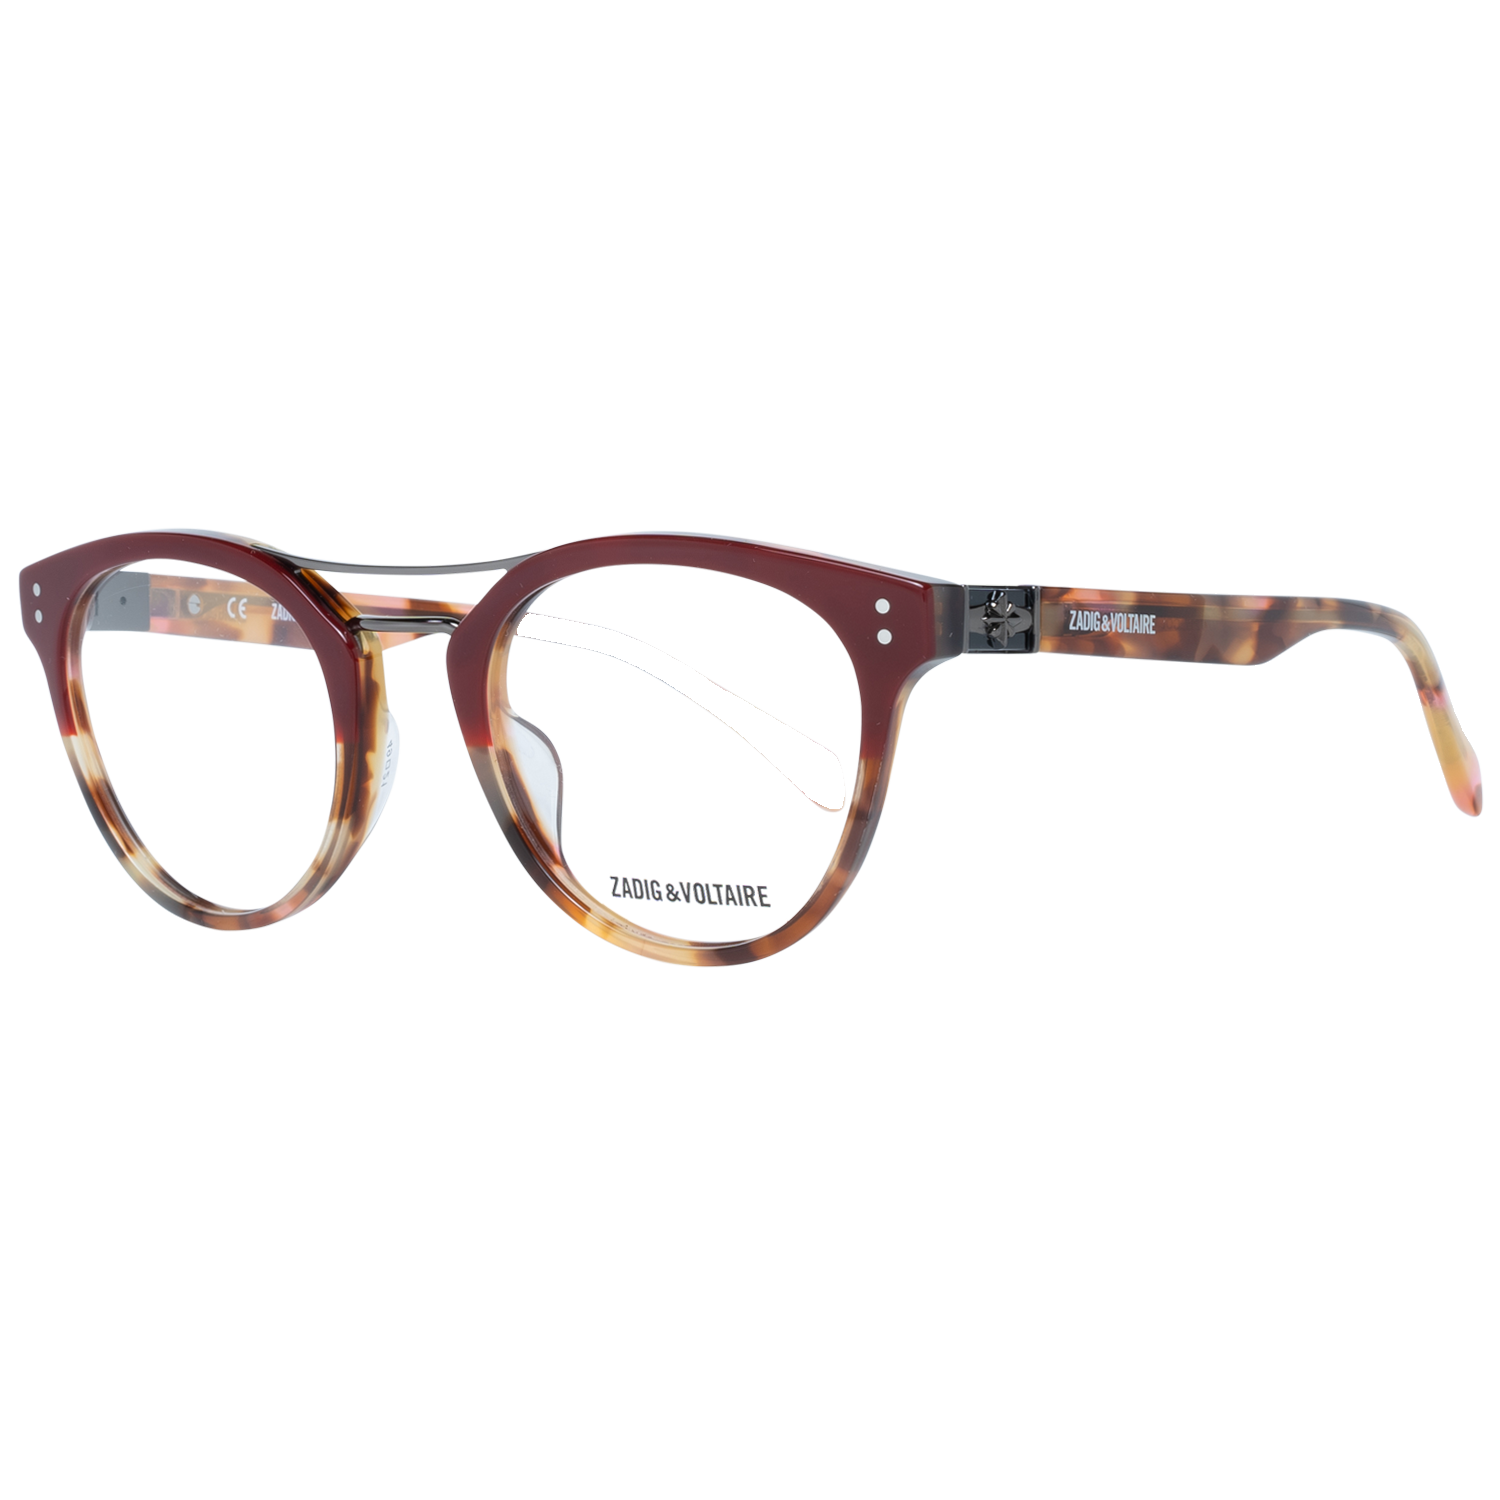

In [20]:
# example usage
result = process_with_NLP("../images/190605154304_00.png")
result

In [ ]:
import os

folder_path = '../images'
output_folder_path = '../output/preserve_nose_bar'

png_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]

for file_name in png_files:
    file_path = os.path.join(folder_path, file_name)
        
   # Apply the process_with_NLP function
    result = process_with_NLP(file_path)

    
    # Display the result
    plt.figure(figsize=(10, 10))
    plt.title(f'Result for {file_name} - 1 time applied', fontsize=20)
    plt.imshow(result)
    plt.axis('off')
    plt.show()
    
    output_file_path = os.path.join(output_folder_path, file_name)
    result.save(output_file_path)
    
    """
    cv2.imwrite('temp.png', np.array(result))
    
    result = process_with_NLP('temp.png')
    
        
    # Display the result
    plt.figure(figsize=(10, 10))
    plt.title(f'Result for {file_name} - 2 times applied', fontsize=20)
    plt.imshow(result)
    plt.axis('off')
    plt.show()
    
    cv2.imwrite('temp.png', np.array(result))
    
    result = process_with_NLP('temp.png')
        
    # Display the result
    plt.figure(figsize=(10, 10))
    plt.title(f'Result for {file_name} - 3 times applied', fontsize=20)
    plt.imshow(result)
    plt.axis('off')
    plt.show()
    
    """